# Decision Trees in Depth: Building, Refining, and Interpreting for Classification Tasks

Decision trees are a type of supervised learning algorithm commonly used for classification and regression tasks (mostly used for classification problems.) They work by recursively splitting the data based on feature values to partition the feature space into distinct regions represented as a tree structure. The goal is to create a model that predicts the target variable by learning simple decision rules inferred from the features.

**Key Characteristics of Decision Trees:**

- **Hierarchical Structure**: At the top, we have the root node that splits into several internal nodes, which then branch out to leaf nodes based on decision rules.



- **Decision Making**: At each internal node, a decision is made based on the value of an input feature, guiding the data to the left or right child node.



- **Termination**: Leaf nodes represent the final decision (or classification). Each path from the root to a leaf node represents a classification decision.



- **Simplicity**: One of the main advantages of decision trees is their simplicity and interpretability. They are easy to visualize, understand, and interpret.



- **Versatility**: Decision trees can handle both categorical and numerical data.


**Construction of Decision Trees:**

The process of constructing a decision tree involves:

- **Feature Selection**: Based on certain criteria (like Gini impurity or information gain), the model selects the best feature to split the data.



- **Binary Splitting**: For the chosen feature, the model determines the best value to split the data into two sets.



- **Recursive Splitting**: Steps 1 and 2 are repeated recursively for each child node until one of the conditions matches: all data in a node belong to a single category, there are no more features left, or a predefined limit of the tree depth is met.



- **Pruning**: This is an optional step to remove branches from the tree. Pruning helps to reduce the complexity of the tree and avoid overfitting.


**Limitations of Decision Trees:**

- **Overfitting**: Without constraints, a decision tree might fit the training data too closely, capturing noise and making it less generalizable to new data.



- **Instability**: Small changes in the data can lead to a different tree structure. This problem can be mitigated using techniques like bagging (used in Random Forests, we will study this topic further next week).



- **Optimality**: The greedy nature of decision tree building (selecting the best feature to split on at each step) doesn't guarantee a globally optimal tree.



<br>

### Heart Disease Dataset

This dataset is utilized to predict the presence of heart disease based on various medical attributes of patients. It's frequently employed in both medical and machine learning research as a benchmark for evaluating the performance of classification models.

Here are the primary features of the dataset and their descriptions:

- age: Age of the patient.
- sex: Gender (1 for male and 0 for female).
- cp: Chest pain type (with four distinct types represented by numbers 1-4).
- trestbps: Resting blood pressure (in mm Hg upon admission to the hospital).
- chol: Serum cholesterol in mg/dl.
- fbs: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false).
- restecg: Resting electrocardiographic results (values 0,1,2).
- thalach: Maximum heart rate achieved.
- exang: Exercise-induced angina (1 = yes; 0 = no).
- oldpeak: ST depression induced by exercise relative to rest.
- slope: The slope of the peak exercise ST segment.
- ca: Number of major vessels (0-3) colored by fluoroscopy.
- thal: A short for thalassemia, a blood disorder (3 = normal; 6 = fixed defect; 7 = reversible defect).


- **hd**: Presence of heart disease (1 = true; 0 = false).





<br>

## Step 1: Import the data

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier # to build a classification tree
from sklearn.tree import plot_tree # to draw a classification tree
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import cross_val_score # for cross validation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix # to create a confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")


In [6]:
! pip install kagglehub


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ritwikb3/heart-disease-cleveland")

print("Path to dataset files:", path)


df = pd.read_csv(path + "/Heart_disease_cleveland_new.csv").head()


Path to dataset files: /Users/nkohei/.cache/kagglehub/datasets/ritwikb3/heart-disease-cleveland/versions/1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5 non-null      int64  
 1   sex       5 non-null      int64  
 2   cp        5 non-null      int64  
 3   trestbps  5 non-null      int64  
 4   chol      5 non-null      int64  
 5   fbs       5 non-null      int64  
 6   restecg   5 non-null      int64  
 7   thalach   5 non-null      int64  
 8   exang     5 non-null      int64  
 9   oldpeak   5 non-null      float64
 10  slope     5 non-null      int64  
 11  ca        5 non-null      int64  
 12  thal      5 non-null      int64  
 13  target    5 non-null      int64  
dtypes: float64(1), int64(13)
memory usage: 692.0 bytes


## Step 2： Exploratory Data Analysis (EDA)

In [109]:
# Check the distribution of the 'target' column
target_distribution = df['hd'].value_counts()

target_distribution

0    164
1    139
Name: hd, dtype: int64

In [110]:
# Identify continuous variables based on unique values and data type
continuous_vars = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and len(df[col].unique()) > 10]

# Descriptive statistics for continuous variables
continuous_stats = df[continuous_vars].describe()
continuous_stats

,age,restbp,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [111]:
#Identify the categorical variables and examine their frequency distribution
def print_count(col):
    print(df[col].value_counts())

cat_cols = ['sex', 'cp', 'fbs','restecg', 'exang', 'slope', 'ca', 'thal']

for col in cat_cols:
    print_count(col)
    print('-' * 20)

1.0    206
0.0     97
Name: sex, dtype: int64
--------------------
4.0    144
3.0     86
2.0     50
1.0     23
Name: cp, dtype: int64
--------------------
0.0    258
1.0     45
Name: fbs, dtype: int64
--------------------
0.0    151
2.0    148
1.0      4
Name: restecg, dtype: int64
--------------------
0.0    204
1.0     99
Name: exang, dtype: int64
--------------------
1.0    142
2.0    140
3.0     21
Name: slope, dtype: int64
--------------------
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: ca, dtype: int64
--------------------
3.0    166
7.0    117
6.0     18
?        2
Name: thal, dtype: int64
--------------------


Alternatively, for more clarity, you could also check these categorical variables one by one.

In [10]:
df['sex'].value_counts()

1.0    206
0.0     97
Name: sex, dtype: int64

In [11]:
df['cp'].value_counts()

4.0    144
3.0     86
2.0     50
1.0     23
Name: cp, dtype: int64

In [12]:
df['fbs'].value_counts()

0.0    258
1.0     45
Name: fbs, dtype: int64

In [13]:
df['restecg'].value_counts()

0.0    151
2.0    148
1.0      4
Name: restecg, dtype: int64

In [14]:
df['exang'].value_counts()

0.0    204
1.0     99
Name: exang, dtype: int64

In [15]:
df['slope'].value_counts()

1.0    142
2.0    140
3.0     21
Name: slope, dtype: int64

In [16]:
df['ca'].value_counts()

0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: ca, dtype: int64

In [17]:
df['thal'].value_counts()

3.0    166
7.0    117
6.0     18
?        2
Name: thal, dtype: int64

## Step 3: Data Preprocessing:

### 1. Missing Data:  Identifying and Dealing With Missing Data

Classification trees don't allow missing inputs. So for any question mark values (in this dataset, they are treated as missing values), we have to decide how to fill them in or handle them.

There are two main approaches:

- Delete rows with missing entries. This is simple, but throws out potentially useful non-missing info. For example, if age is missing but everything else is useful, it's wasteful to discard the full row.


- Impute the missing values. "Impute" just means making an educated guess at reasonable fill-in values. Instead of dropping rows, we fill holes with estimates like mean or median age. More advanced methods can make even better guesses.

The right approach depends on the importance of the missing variable for classification. If age doesn't matter much, imputation works fine. But for critical variables, it may be better to discard rows with missing entries.
We have to weigh the tradeoffs - imputation preserves data but introduces possible noise. Deletion is cleaner but wastes non-missing information. We need to look at the pattern of missingness and decide how best to handle it.



In [26]:
# show the rows that contain missing values.
df.loc[(df['ca'] == '?') | (df['thal'] == '?')]

,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In this dataset, the 'ca' and 'thal' features are very important. Also, there are very few missing values, so we can opt to simply remove them

In [31]:
## use loc[] to select all rows that do not contain missing values

df_cleaned = df.loc[(df['ca'] != '?')  & (df['thal'] != '?')]
df_cleaned.shape

(297, 14)

In [32]:
df_cleaned['ca'].unique()

array(['0.0', '3.0', '2.0', '1.0'], dtype=object)

In [33]:
df_cleaned['thal'].unique()

array(['6.0', '3.0', '7.0'], dtype=object)

**NOTE:** We handle missing data before dividing into X and y to ensure that every row in X aligns accurately with its corresponding value in y. This prevents any mismatch if rows are removed.


### 2. Split the Data into Dependent/Target and Independent Variables/Features

For the upcoming One-Hot Encoding, we first split the dataset into two parts - the columns of data that we will use to make classifications (capital **X**), and the column of data that we want to predict (lower case **y**) .

In [34]:
X = df_cleaned.drop('hd', axis=1)
X.head()

,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


In [36]:
y = df_cleaned['hd']
y.tail()

297    1
298    1
299    1
300    1
301    1
Name: hd, dtype: int64


### 3: One-Hot Encoding

Now, let's review the One-Hot Encoding method that we learned previously in course 522. First, let's take closer look at the categorical variables and their levels in this dataset


- **sex** - **Category**
  - 0 = female
  - 1 = male
- **cp**, chest pain, **Category**
  - 1 = typical angina
  - 2 = atypical angina
  - 3 = non-anginal pain
  - 4 = asymptomatic
- **fbs**, fasting blood sugar, **Category**
  - 0 = >=120 mg/dl
  - 1 = <120 mg/dl
- **restecg**, resting electrocardiographic results, **Category**
  - 1 = normal
  - 2 = having ST-T wave abnormality
  - 3 = showing probable or definite left ventricular hypertrophy
- **exang**, exercise induced angina, **Category**
  - 0 = no
  - 1 = yes
- **slope**, the slope of the peak exercise ST segment, **Category**
  - 1 = upsloping
  - 2 = flat
  - 3 = downsloping
- **thal**, thalium heart scan, **Category**
  - 3 = normal (no cold spots)
  - 6 = fixed defect (cold spots during rest and exercise)
  - 7 = reversible defect (when cold spots only appear during exercise)


**One-Hot Encoding** is a technique employed to convert categorical data into a format that can be fed into machine learning models. Instead of having a single feature represent multiple categories, this method expands the feature space such that each category gets its own dedicated binary feature.

**Scikit-learn decision trees can directly handle continuous numerical features like age, blood pressure, cholesterol etc. However, they cannot naturally deal with categorical features that take on a limited set of values**, like chest pain type.

For example, the chest pain type (cp) column has 4 categorical values:

1 - Typical angina

2 - Atypical angina

3 - Non-anginal pain

4 - Asymptomatic

Treating these as numeric values implies a similarity relationship between them.

The decision tree will assume 4 (asymptomatic) is more similar to 3 (non-anginal pain) than 1 or 2 (angina types). It may cluster patients with values 3 and 4 together. But these categories have no inherent numeric relationship. Asymptomatic is not actually more similar to non-anginal pain than other chest pain types.

With proper categorical encoding, each value is treated as a separate unrelated category. Patients with value 4 are no more likely to cluster with 3 than with 1 or 2. The decision tree will simply learn patterns independently in each category rather than assuming ordered similarity.

To wrap up, categorical values don't have numeric meanings. Enforcing a numeric treatment creates false ordinal relationships. Proper encoding is needed to represent categories without incorrect ordinal assumptions.


<br>

There are several ways to do **one-hot encoding** in Python. `ColumnTransformer` from scikit-learn and `get_dummies` from pandas are two common approaches with tradeoffs.

`ColumnTransformer` has useful persistence behavior. If the training data encodes "fruit", "vegetable" and "meat" for a "food type" feature, it remembers these categories. Later, when encoding a new unseen value like "seafood", it can raise an error or handle it properly since seafood wasn't seen before. The limitation is `ColumnTransformer` encodes into arrays, losing column names. This makes inspecting the encoded columns for debugging harder.

In contrast,`get_dummies` retains the dataframe structure and column names when encoding. This greatly simplifies verifying the encoded columns. However, `get_dummies` lacks the persistence of `ColumnTransformer` to validate new categories. For initial one-hot encoding concepts, `get_dummies` is preferable as it avoids array abstraction and keeps informative column names. But `ColumnTransformer` is better suited for production systems that need to robustly handle new categorical data.

In summary, `get_dummies` is good for learning while `ColumnTransformer` is recommended for building robust models handling categories.

In this tutorial, we will use the `get_dummies()` function to perform one-hot encoding, but keep in mind that there are other ways to do this.

In [37]:
X['cp'].unique()

array([1., 4., 3., 2.])

In [38]:
pd.get_dummies(X, columns=['cp']).head()

,age,sex,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_1.0,cp_2.0,cp_3.0,cp_4.0
0,63.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,1,0,0,0
1,67.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,0,0,0,1
2,67.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,0,0,0,1
3,37.0,1.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0,1,0
4,41.0,0.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,1,0,0


When using `get_dummies()` for one-hot encoding, the original unmodified columns are placed first in the dataframe. The encoded columns from the categorical feature come after.

For the chest pain (cp) column, `get_dummies()` created 4 new columns named cp_1, cp_2, cp_3, and cp_4.

These correspond to the 4 original cp categories. cp_1 has 1s for observations with cp value 1, 0s otherwise. Or in other words, typical angina may get a column with 1s for all rows labeled as typical angina. 0s for other categories.

cp_2.0 has 1s only for observations with cp value 2. cp_3.0 has 1s for cp value 3 and so on.

So each coded column represents one of the original categories using binary 1/0 indicators.

The single categorical cp column has been expanded into multiple columns encoding the different categories.This allows decision trees and other ML models to split and learn on the categories independently, as regular numeric features. The encoding avoids imposing any ordinal relationship between categories.

In summary, inspecting the one-hot encoded columns confirms that the categorical feature has been properly converted into multiple numeric columns, each representing one category using 0/1 binary indicators. This enables downstream usage with machine learning algorithms.

In [39]:
#Let's also perform one-hot encoding on the other categorical variables
X_encoded = pd.get_dummies(X, columns=['cp', 
                                       'restecg', 
                                       'slope', 
                                       'thal'])
X_encoded.head()

,age,sex,restbp,chol,fbs,thalach,exang,oldpeak,ca,cp_1.0,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,1,...,0,0,0,1,0,0,1,0,1,0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,0,...,1,0,0,1,0,1,0,1,0,0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,0,...,1,0,0,1,0,1,0,0,0,1
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,...,0,1,0,0,0,0,1,1,0,0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,...,0,0,0,1,1,0,0,1,0,0


In this dataset, there are 3 categorical features that already contain binary 0/1 values - sex, fbs, and exang. These 3 variables inherently have only 2 possible categories that are encoded as binary values. In contrast, a variable like chest pain type (cp) has multiple categories that need to be one-hot encoded into multiple 0/1 columns. Since sex, fbs and exang are already binary categorical indicators, they do not require any further encoding. 

### 4. split the data into training and test sets

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((222, 22), (75, 22), (222,), (75,))

5. **Decision trees do not require feature scaling** because the tree-building process is based on recursively partitioning the feature space, not the absolute values of the features. Decision trees rely on relative importance of features rather than absolute values. They can directly handle numeric and categorical data without standardization. The tree structure remains unchanged regardless of feature scales. No distance calculations are involved internally that need normalized features. In summary, decision trees work with raw unscaled features due to their scale-invariant nature.

## Step 4: Build A Preliminary Classification Tree

In [112]:
# create a decisiont tree 
clf_dt = DecisionTreeClassifier(random_state=42)

#train the decision tree classifier on our training data.
clf_dt = clf_dt.fit(X_train, y_train) 


# Predict the classifications on the test set
y_pred = clf_dt.predict(X_test)


# Calculate accuracy
accuracy_val = accuracy_score(y_test, y_pred)
accuracy_val

0.76

#### confusion matrix

The Confusion Matrix is a table used to evaluate classification models. It consists of:

- True Positives (TP): Correctly predicted as positive.

- True Negatives (TN): Correctly predicted as negative.

- False Positives (FP): Incorrectly predicted as positive.

- False Negatives (FN): Incorrectly predicted as negative.

*We haven't covered confusion matrix just yet; it will be addressed in week five or six. If you're interested, you can take a look.*

In [70]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

accuracy_val, conf_matrix

(0.76,
 array([[31, 11],
        [ 7, 26]]))

<Figure size 500x500 with 0 Axes>

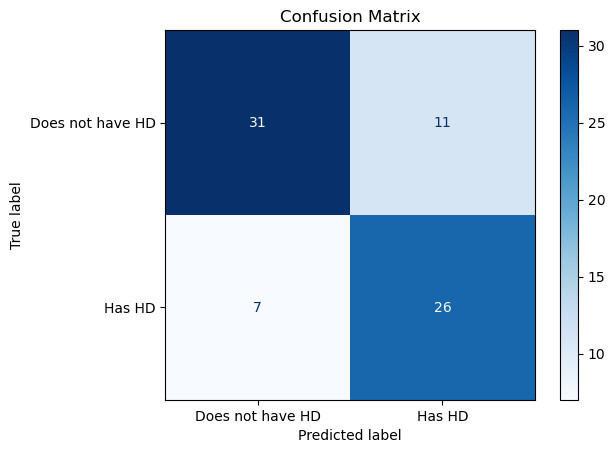

In [79]:
# Plotting the confusion matrix 
plt.figure(figsize=(5, 5))
plot_confusion_matrix(clf_dt, X_test, y_test, display_labels=["Does not have HD", "Has HD"], cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

From the matrix, we can see:

- True Positives (TP) = 26 (Correctly predicted "Has HD")
- True Negatives (TN) = 31 (Correctly predicted "No HD")
- False Positives (FP) = 11 (Incorrectly predicted "Has HD" when it was "No HD")
- False Negatives (FN) = 7 (Incorrectly predicted "No HD" when it was "Has HD")

Accuracy = (True positives + True Negatives)/ (True positives + True negatives + False positives + False negatives)

Accuracy = (26 + 31)/ (26 + 31 + 11 + 7) = 0.76

It also shows how many samples were correctly or incorrectly classified for each actual class.

Out of 42 test samples where the true label was 'No Heart Disease':

- 31 were correctly predicted as 'No Disease' (true negatives)
- 11 were incorrectly predicted as 'Disease' (false positives)

So the model had 74% accuracy (31/42) for the true no disease class.

Out of 33 test samples where the true label was 'Heart Disease':

- 26 were correctly predicted as 'Disease' (true positives)
- 7 were incorrectly predicted as 'No Disease' (false negatives)

So accuracy was 79% (26/33) for the true disease class.

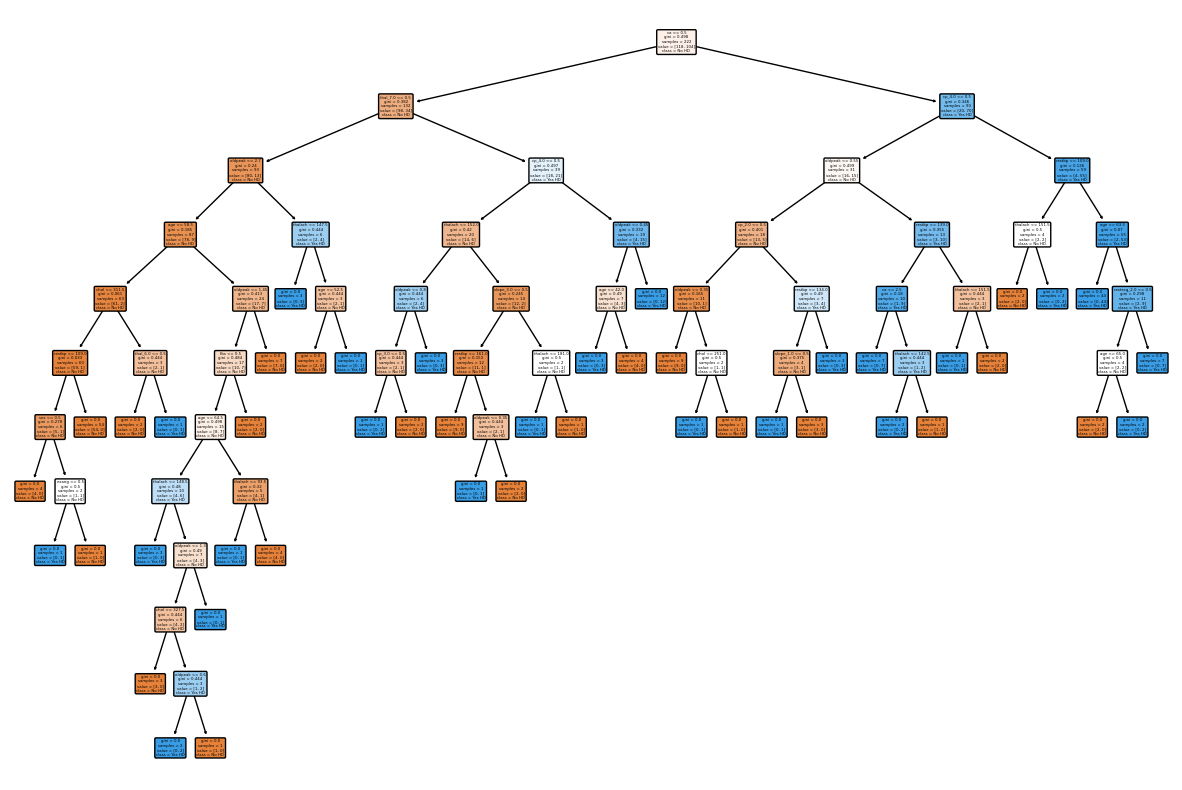

In [56]:
# plot the tree 
plt.figure(figsize=(15, 10))
plot_tree(clf_dt, 
          filled=True, #Fills the boxes with colors. The colors indicate the majority class.
          rounded=True, #Rounds the corners of the boxes for aesthetic purposes.
          class_names=["No HD", "Yes HD"], #the labels for the two classes we're predicting.
          feature_names=X_encoded.columns); #the names of the features, so they can be displayed on the tree.

We can see that this decision tree is very big and complicated. This makes it hard to understand and likely to overfit to the training data. Our initial model is okay, but it's probably learning some random patterns that won't apply to new data. To fix this, we can prune the tree to simplify it. Pruning removes unnecessary branches so the tree isn't so complex.
Let's try pruning our tree. This may improve the model by making it easier to interpret and generalize better to new data.


## Step 4: Cost Complexity Pruning Part 1: Visualize alpha

Decision trees can easily overfit to the data they are trained on. There are tuning knobs like `max_depth` and `min_samples` which we learned about in our lectures to try to prevent overfitting, but it's tricky to find the right balance.  Cost complexity pruning takes a more direct approach - it builds a big bushy tree on the training data, then prunes it back to find a simpler subtree that generalizes better to new data. The pruning process automates finding a good tree size that avoids overfitting.

Scikit-learn's `DecisionTreeClassifier` provides a method called `cost_complexity_pruning_path`, which returns the effective alphas (values at which the splits occur) and the corresponding total leaf impurities. We can use these values to determine the path for pruning.

So we can say that pruning a decision tree is about figuring out the best setting for the alpha parameter, which decides how much we trim the tree. A higher alpha trims more, giving us a simpler tree.

Here's what we do:

- Calculate cost at every node: The cost is like a score - it's the tree's error rate times the leaf nodes plus alpha times the total nodes. Start trimming from the bottom of the tree where the cost is smallest.Keep increasing alpha and repeat the above. This gives us a bunch of different trees. Use cross-validation to find out which tree is the best out of all these. Pick that best tree as our final one.

To get the right alpha, we plot the tree's accuracy for different alpha values using both our training and testing data. Also, a heads-up, we skip the largest alpha value because it'd trim everything, leaving just the root. Through this approach, cross-validation makes sure we don't over-trim, and we end up with a tree that's both accurate and not too complicated.

In [80]:
path = clf_dt.cost_complexity_pruning_path(X_train, y_train) # determine values for alpha
ccp_alphas = path.ccp_alphas # extract different values for alpha
ccp_alphas = ccp_alphas[:-1] # exclude the maximum value for alpha

clf_dts = [] # create an array that we will put decision trees into

## now create one decision tree per value for alpha and store it in the array
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf_dt.fit(X_train, y_train)
    clf_dts.append(clf_dt)

I noticed that in the week 2 assignment, many students used visualization to showcase different values of alpha, which was very insightful. Here, we can also visualize the values of alpha to examine the relationship between accuracy and alpha for both training and testing sets

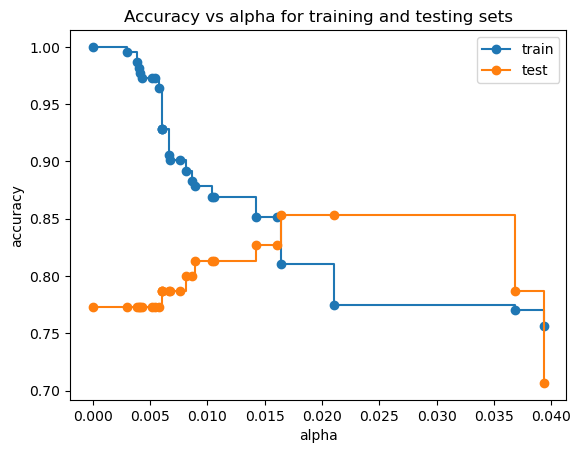

In [81]:
train_scores = [clf_dt.score(X_train, y_train) for clf_dt in clf_dts]
test_scores = [clf_dt.score(X_test, y_test) for clf_dt in clf_dts]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax.legend()
plt.show()

From the plot, we can see how accuracy evolves as the alpha value changes. 

At the Beginning: When alpha is near 0, the accuracy on the training data is very high, but the accuracy on the test data is lower. This might suggest that the model is overfitting to the training data.

As alpha Increases: The accuracy on the training data starts to decrease, while the accuracy on the test data rises, reaching a peak. This peak represents the best performance of the model on the test data and is the optimal alpha value we're aiming for.

Further Increase in alpha: The accuracy on the test data begins to decline, implying that the model might be becoming too simplistic, resulting in reduced performance.

From the graph, it's evident that the test accuracy is maximized when alpha is approximately 0.016. This suggests that alpha=0.016 is potentially the best pruning parameter since the model performs best on the test data at this point.

## Step 5:  Cost Complexity Pruning Part 2: Cross Validation For Finding the Best Alpha

Let's revisit the cross validation concept we learned in week 2:

The main idea is: split the entire available dataset into multiple subsets, use one subset for validation and the rest for training. Repeat this process, each time choosing a different subset as the validation set. Finally, average or take other statistics across the validation results.
The advantages of this are that all the data gets used for both training and validation, and it reduces variance to get a more reliable estimate of model performance.


The chart we plotted indicates an optimal value for alpha as 0.016. However, when analyzing a different dataset, we might arrive at a different ideal alpha value. It's important to note that the choice of alpha is considered a Hyperparameter. This distinguishes it from other parameters that the Decision Tree algorithm can determine autonomously. To illustrate how varying training and testing sets can lead to different model accuracies with `ccp_alpha` set to 0.016, we'll employ the `cross_val_score()` function. This allows us to create diverse datasets, on which we will train and evaluate our decision tree model.

We'll employ 5-fold cross validation to generate five distinct training and testing sets to train and evaluate our tree. We've chosen 5-fold primarily due to our dataset's limited size

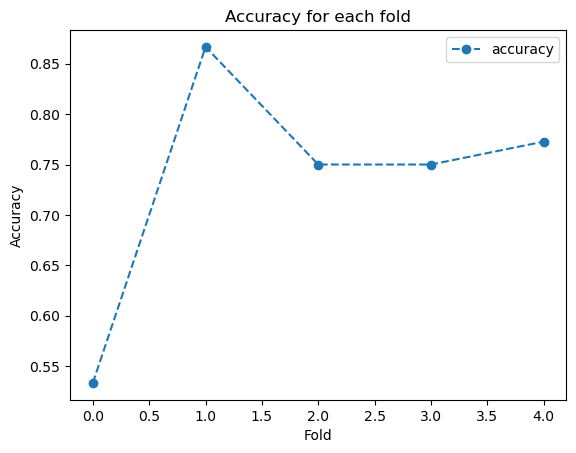

In [93]:
# Perform 5-fold cross-validation
scores = cross_val_score(clf_dt, X_train, y_train, cv=5)

# Convert the scores to a DataFrame and plot
df = pd.DataFrame(data={'tree': range(5), 'accuracy': scores})
ax = df.plot(x='tree', y='accuracy', marker='o', linestyle='--', title="Accuracy for each fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
plt.show()

The graph shows how accuracy changes across different rounds of our 5-fold cross-validation. Each point represents how well the model did in a specific round. In this 5-fold method, the data is split into five parts. For each test, four parts are used to train the model and one part to test it. The whole numbers (0, 1, 2, 3, 4) on the x-axis mark these five tests. The in-between values like 0.5, 1.5 are just there for looks and don't mean anything special.

This chart highlights why using cross-validation is important. By checking the model's performance over different data splits, we can see how stable and reliable the model is. It's a reminder that we shouldn't just use one set of training and testing data, but test the model in different situations to make sure it works well overall.

Now let's use *cross validation* to find the optimal value for `ccp_alpha`. (*The ccp_alpha parameter in decision tree algorithms stands for "Cost Complexity Pruning - Alpha.*)

<AxesSubplot:xlabel='alpha'>

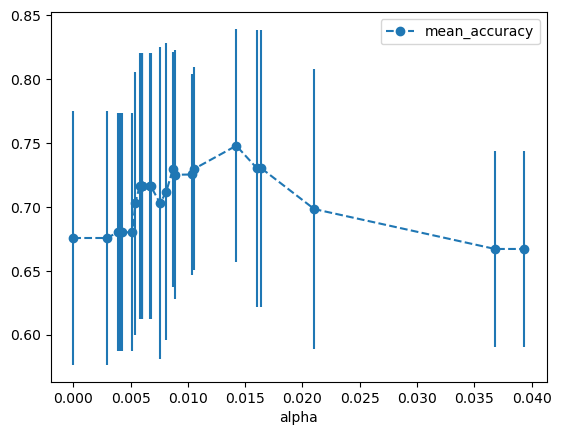

In [94]:
## create an array to store the results of each fold during cross validiation
alpha_loop_values = []

## For each candidate value for alpha, we will run 5-fold cross validation.
## Then we will store the mean and standard deviation of the scores (the accuracy) for each call
## to cross_val_score in alpha_loop_values...
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
    alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])

## Now we can draw a graph of the means and standard deviations of the scores
## for each candidate value for alpha
alpha_results = pd.DataFrame(alpha_loop_values, 
                             columns=['alpha', 'mean_accuracy', 'std'])

alpha_results.plot(x='alpha', 
                   y='mean_accuracy', 
                   yerr='std', 
                   marker='o', 
                   linestyle='--')

From the plot, we can observe how the model's average accuracy fluctuates with varying values of `ccp_alpha`. Each distinct `ccp_alpha` value corresponds to a specific average accuracy. The error bars represent the standard deviation of the accuracy, giving us an insight into the stability of the model's performance. As we note, with the increase in `ccp_alpha`, the model's average accuracy initially ascends to a peak and then commences its descent. The peak accuracy is achieved around a `ccp_alpha` of approximately 0.014.

Previously, in part 1, we identified `ccp_alpha≈0.016` based on one specific train-test split. Later, through cross-validation, we determined `ccp_alpha≈0.014`. This latter value offers a more comprehensive estimate since it accounts for multiple validation sets. Hence, in this case, `ccp_alpha≈0.014` is the preferable choice as it's likely more robust across varied data splits.

We can find the exact value with:

In [95]:
alpha_results[(alpha_results['alpha'] > 0.014)
              &
              (alpha_results['alpha'] < 0.015)]

,alpha,mean_accuracy,std
20,0.014225,0.747778,0.091395


Let's save the optimal alpha value, so we can use it to construct the most effective tree.

In [86]:
ideal_ccp_alpha = alpha_results[(alpha_results['alpha'] > 0.014) 
                                & 
                                (alpha_results['alpha'] < 0.015)]['alpha']
ideal_ccp_alpha

20    0.014225
Name: alpha, dtype: float64

Currently, Python perceives `ideal_ccp_alpha` as a series, a kind of array. This is evident when we print `ideal_ccp_alpha`, as it provides two pieces of information. The first, 20, represents the series index, and the second, 0.014225, is the value we're interested in. We can transform this from a series to a float using the subsequent command:

Or we can directly use `ccp_alpha`=0.014225

In [96]:
# convert ideal_ccp_alpha from a series to a float
ideal_ccp_alpha = float(ideal_ccp_alpha)
ideal_ccp_alpha

0.014224751066856332

With the optimal alpha value in hand, we're now equipped to construct, assess, and visualize our ultimate Classification Tree.


## Step 6: Building, Evaluating, Drawing, and Interpreting the Final Classification Tree

Now that we have determined the optimal value for alpha, we can construct the final Classification Tree by setting `ccp_alpha` to the calculated `ideal_ccp_alpha`.

In [97]:
# Build and train a new decision tree, only this time use the optimal value for alpha
clf_dt_pruned = DecisionTreeClassifier(random_state=42, 
                                       ccp_alpha=ideal_ccp_alpha) # or ccp_alpha=0.014224751066856332
clf_dt_pruned = clf_dt_pruned.fit(X_train, y_train) 

In [100]:
# Predict the classifications on the test set using the pruned tree
y_pred_pruned = clf_dt_pruned.predict(X_test)

# Calculate accuracy for the pruned tree
accuracy_val_pruned = accuracy_score(y_test, y_pred_pruned)


accuracy_val_pruned

0.8266666666666667

In [101]:
# Generate the confusion matrix for the pruned tree
conf_matrix_pruned = confusion_matrix(y_test, y_pred_pruned)

accuracy_val_pruned, conf_matrix_pruned

(0.8266666666666667,
 array([[34,  8],
        [ 5, 28]]))

Now let's draw another confusion matrix to see if the pruned tree does better.

<Figure size 500x500 with 0 Axes>

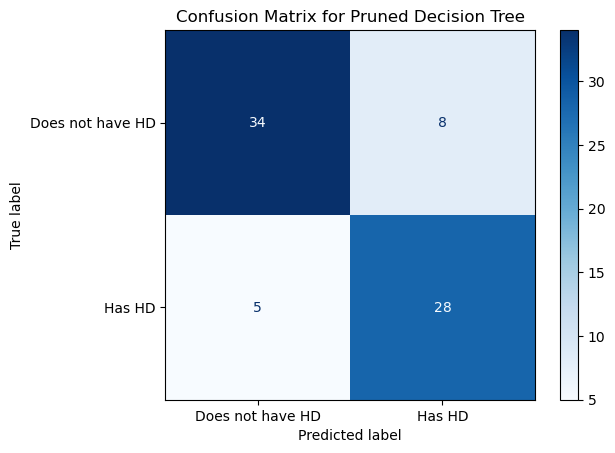

In [118]:
# Plot the confusion matrix for the pruned tree 
plt.figure(figsize=(5, 5))
plot_confusion_matrix(clf_dt_pruned, X_test, y_test, display_labels=["Does not have HD", "Has HD"], cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Pruned Decision Tree")
plt.show()


Accuracy = (True positives + True Negatives)/ (True positives + True negatives + False positives + False negatives)

Accuracy = (28 + 34)/ (28 + 34 + 8 + 5) = 0.8266666666666667

The pruned Decision Tree demonstrates enhanced performance in patient classification compared to the unpruned tree.

From the test data:

Out of the 34 + 8 = 42 individuals who were diagnosed without heart disease:
34 (81%=34/42) were accurately classified by our pruned model.
In comparison, the unpruned model had a slightly lower success rate, correctly classifying 31 (74%) of these individuals.

On the flip side, for the 5 + 28 = 33 individuals diagnosed with heart disease:
A commendable 28 (85%) were correctly pinpointed by our pruned tree. In comparison, the unpruned version of our model managed to correctly classify 26 (79%) of these patients.

The results clearly indicate the benefits of pruning. It not only refines the model but also enhances its precision in real-world scenarios. This underlines the importance of model optimization techniques, such as pruning, in ensuring better and more reliable outcomes.

The last thing we are going to do is draw the pruned tree and discuss how to interpret it.

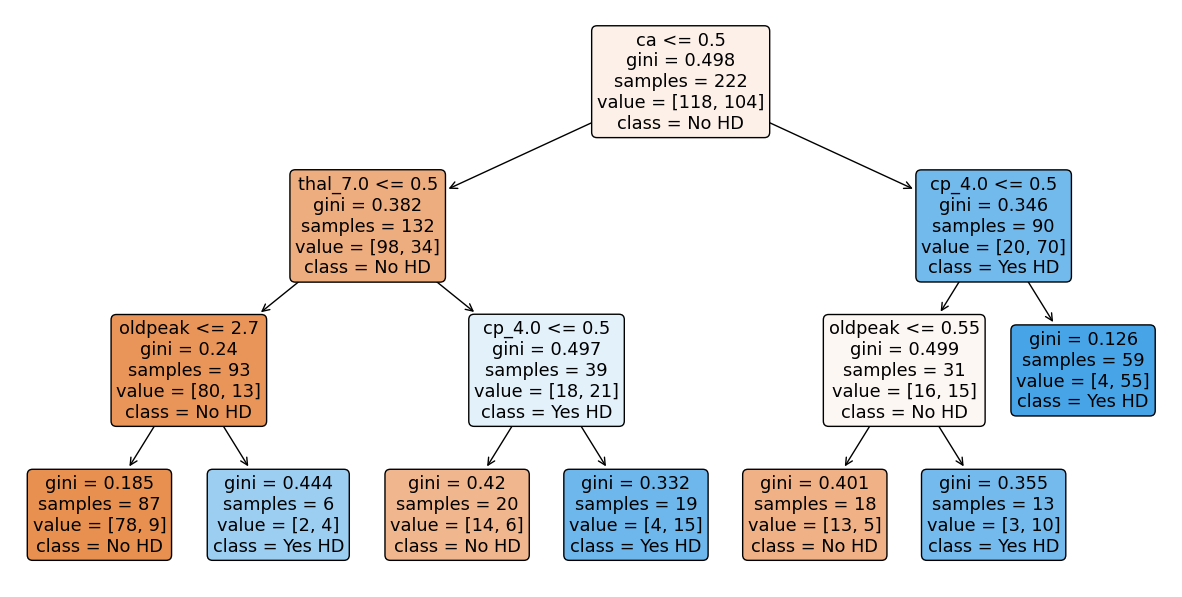

In [114]:
plt.figure(figsize=(15, 7.5))
plot_tree(clf_dt_pruned, 
          filled=True, 
          rounded=True, 
          class_names=["No HD", "Yes HD"], 
          feature_names=X_encoded.columns); 

Now let's talk about how to interpret the tree.

First, let's review some key concepts of this decision tree：

- **Splitting criteria**: At each node, there is a specific variable and associated threshold that determines how to split the data. For example, at the root of the tree, the variable "ca" is used as the criteria. If an observation's "ca" value is less than or equal to 0.5, it will be directed to the left branch; otherwise, it will go to the right branch.


- **Gini index**: The "gini" at each node represents the impurity or disorder of the data in that node. It quantifies how mixed the classes are in each node - a low Gini index indicates the data is mostly homogeneous and split towards one particular class. The Gini index ranges from 0 (completely homogeneous) to 1 (equally mixed). To choose the optimal split at each node, decision tree algorithms will pick the criteria that results in child nodes with the lowest Gini indices. This week we did not go in depth into how to calculate the Gini index. Overall, the lower the Gini index, the more inclined the data in that node is towards a particular class.


- **Sample count**: The "samples" at each node indicates the number of observations in that node.


- **Class distribution**: The "value" at each node gives the number of samples split into each result class. In this example there are two classes: "No" (indicating no heart disease) and "Yes" (indicating heart disease). The count for "No" is listed first since the classes are sorted alphabetically. So at the root node, there are 118 "No" and 104 "Yes".


- **Dominant class**: The "class" at each node indicates the predominant class in that node. At the root, "No" is the dominant class since there are 118 "No" and 104 "Yes". If we make a decision at a node without further splitting it downwards, then we would predict new instances based on the dominant class of that node.


- **Leaf nodes**: Leaf nodes are the final outcomes of the decision tree. They are similar to other nodes but have no further splitting criteria.


- **Color coding**: The color of the nodes and leaf nodes in this decision tree depends on their dominant class. In this example, "No" is coded with orange hues while "Yes" is coded with blue hues. The darker the color, the lower the Gini index, meaning the node or leaf is more inclined towards one particular class.

<br>

**Note:** Recall that we performed one-hot encoding on the dataset. For example, for the feature `thal`, which has three categories (3, 6, and 7), we created three new binary (meaning they can only be 0 or 1) features:

- `thal_3.0` is 1 if thal is 3, and 0 otherwise.
- `thal_6.0` is 1 if thal is 6, and 0 otherwise.
- `thal_7.0` is 1 if thal is 7, and 0 otherwise.

In the decision tree, we see a condition `thal_7.0 <= 0.5`, it's really just checking if `thal` is 7. If `thal` is 7, `thal_7.0` will be 1 (which is greater than 0.5). If `thal` isn't 7, `thal_7.0` will be 0 (which is equal to or less than 0.5).

So, that condition `thal_7.0 <= 0.5` is simply separating samples based on whether `thal` is 7 or not.

<br>

**Example**: Now let's walk through the decision tree with a new patient example:

First, let's establish our patient's data (new example):

- ca = 2 
- thal= 6 
- oldpeak = 2.3 
- cp = 1.0 

Step 1: The root node split criteria is: ca ≤ 0.5. Our patient's ca value is 2, so this criteria is not met. We take the right branch.

Step 2: The next node splits on cp_4.0 ≤ 0.5. Our patient's cp value is 1.0, so cp_4.0 equals 0 (less than 0.5), and we take the left branch. In other words, "cp not equal 4" is true so we go left.

Step 3: The next node splits on oldpeak ≤ 0.55. Our patient's oldpeak is 2.3, so this criteria is not met. We take the right branch to the terminal node: Yes HD.

Therefore, the decision tree predicts that this patient does have heart disease. The model correctly predicted heart disease in 85% of test cases based on the confusion matrix. This shows the model is generally reliable at predicting patients with heart disease